In [30]:
import os
import sys

sys.path.append("..")
from src import RASPRoutines

RASP = RASPRoutines.RASP_Routines()
import pandas as pd
from src import AnalysisFunctions

A_F = AnalysisFunctions.Analysis_Functions()
from src import IOFunctions

from src import Image_Analysis_Functions

IA_F = Image_Analysis_Functions.ImageAnalysis_Functions()

from src import CoincidenceFunctions

C_F = CoincidenceFunctions.Coincidence_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

IO = IOFunctions.IO_Functions()
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

import polars as pl
from scipy.signal import fftconvolve, convolve
from scipy.ndimage import binary_opening, binary_closing, binary_fill_holes
import skimage as ski

from scipy import stats

from scipy import ndimage as ndi
from skimage import (
    exposure,
    feature,
    filters,
    io,
    measure,
    morphology,
    restoration,
    segmentation,
    transform,
    util,
)
from skimage.measure import label, regionprops_table
import napari

In [2]:
# frontal_region_PD = r'/scratch/sycamore-asap/ASAP_Imaging_Data/Main_Survey/20241105_oligomers_in_cells/frontal/microglia/PD_analysis'
frontal_region_HC = r"/scratch/sycamore-asap/ASAP_Imaging_Data/Main_Survey/20241105_oligomers_in_cells/frontal/microglia/HC_analysis"

# oligomer_data_PD = pl.read_csv(os.path.join(frontal_region_PD, 'spot_analysis.csv'))
oligomer_data_HC = pl.read_csv(os.path.join(frontal_region_HC, "spot_analysis.csv"))

In [3]:
folder_to_save = r"/scratch/sycamore-asap/ASAP_Plots/Microglia_HC"

In [4]:
filenames = np.unique(oligomer_data_HC["image_filename"].to_numpy())

In [5]:
def add_alpha_column(oligomer_data, max_intensity=3000):
    """
    Add alpha column to oligomer data based on intensity percentile ranking.

    This is needed for visualization - alpha represents the relative intensity
    of each oligomer as a percentile (0-1).

    Parameters:
    -----------
    oligomer_data : polars.DataFrame
        DataFrame with 'sum_intensity_in_photons' column
    max_intensity : float
        Maximum intensity threshold for filtering (default 3000)

    Returns:
    --------
    oligomer_data : polars.DataFrame
        DataFrame with added 'alpha' column
    """
    # Filter out very bright spots (likely artifacts)
    oligomer_data = oligomer_data.filter(
        pl.col("sum_intensity_in_photons") < max_intensity
    )

    # Calculate percentile ranking (0-1) based on intensity
    percentile = oligomer_data["sum_intensity_in_photons"].rank() / len(
        oligomer_data["sum_intensity_in_photons"]
    )

    # Add as 'alpha' column for visualization
    oligomer_data = oligomer_data.with_columns(percentile.alias("alpha"))

    return oligomer_data

In [6]:
# Add alpha column to oligomer data for visualization
oligomer_data_HC = add_alpha_column(oligomer_data_HC, max_intensity=3000)

print(f"Oligomer data shape: {oligomer_data_HC.shape}")
print(f"Columns: {oligomer_data_HC.columns}")
print(
    f"\nAlpha range: {oligomer_data_HC['alpha'].min():.3f} to {oligomer_data_HC['alpha'].max():.3f}"
)
print(
    f"Intensity range: {oligomer_data_HC['sum_intensity_in_photons'].min():.1f} to {oligomer_data_HC['sum_intensity_in_photons'].max():.1f}"
)

Oligomer data shape: (15541535, 11)
Columns: ['y', 'x', 'z', 'sum_intensity_in_photons', 'bg_per_punctum', 'bg_per_pixel', 'incell', 'zi', 'zf', 'image_filename', 'alpha']

Alpha range: 0.000 to 1.000
Intensity range: 0.0 to 2999.6


In [7]:
def microglia_image_saver(
    filenames,
    analysis_folder,
    folder_to_save,
    protein_string="C1",
    cell_string="C0",
    lower_object_size=2000,
    lower_hole_size=100,
):
    for filename in filenames:
        cell_filename = (
            filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
        )
        raw_cell_image = np.nanmax(IO.read_tiff_tophotons(cell_filename), axis=0)

        mask = np.array(
            IO.read_tiff(
                os.path.join(
                    analysis_folder,
                    os.path.split(filename)[-1].split(protein_string + ".tif")[0]
                    + cell_string
                    + "_cellMask.tiff",
                )
            ),
            dtype=bool,
        )
        filled = ndi.binary_fill_holes(mask)

        mask = morphology.remove_small_holes(filled, area_threshold=lower_hole_size)
        mask = morphology.remove_small_objects(mask, min_size=lower_object_size)
        mask_toplot = np.sum(mask, axis=0).clip(0, 1)
        fig, axs = plotter.one_column_plot()
        savestring = (
            os.path.split(filename)[-1].split(protein_string + ".tif")[0]
            + cell_string
            + "_examplemicroglia.svg"
        )
        axs[0] = plotter.image_plot(
            axs=axs[0],
            data=raw_cell_image,
            plotmask=True,
            mask=mask_toplot,
            cbar="off",
            masklinewidth=0.5,
        )
        plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format="svg")
        plt.show(block=False)
    return

In [ ]:
microglia_image_saver(
    filenames, frontal_region_HC, folder_to_save, lower_object_size=0, lower_hole_size=0
)

In [8]:
from skimage.filters import gaussian, threshold_li


def detect_large_features(
    image, filter, sigma1=2.0, sigma2=60.0, hole_threshold=100, cell_threshold=2000
):
    large_mask = np.zeros_like(image)
    for i in np.arange(image.shape[0]):
        enhanced_image = gaussian(
            image[i, :, :], sigma=sigma1, truncate=2.0
        ) - gaussian(image[i, :, :], sigma=sigma2, truncate=2.0)

        # Create a binary mask for large features based on the threshold
        large_mask[i, :, :] = enhanced_image > filter(enhanced_image)

        large_mask[i, :, :] = binary_opening(
            large_mask[i, :, :], structure=ski.morphology.disk(1)
        )
        large_mask[i, :, :] = binary_closing(
            large_mask[i, :, :], structure=ski.morphology.disk(5)
        )
    large_mask = ndi.binary_fill_holes(large_mask)
    large_mask = morphology.remove_small_holes(
        large_mask, area_threshold=hole_threshold
    )
    large_mask = morphology.remove_small_objects(large_mask, min_size=cell_threshold)
    return large_mask.astype(bool)

In [9]:
def microglia_image_saver_3D(
    filenames,
    oligomer_analysis,
    filter,
    folder_to_save,
    protein_string="C1",
    cell_string="C0",
    lower_object_size=2000,
    lower_hole_size=100,
):
    for filename in filenames:
        filename = str(filename)
        specific_image = oligomer_analysis.filter(pl.col("image_filename") == filename)
        zi = int(np.unique(specific_image["zi"].to_numpy()))
        zf = int(np.unique(specific_image["zf"].to_numpy()))
        cell_filename = (
            filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
        )
        raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]
        mask = detect_large_features(
            raw_cell_image,
            filter,
            sigma1=2.0,
            sigma2=40.0,
            hole_threshold=100,
            cell_threshold=2000,
        )
        mask_toplot = np.sum(mask, axis=0).clip(0, 1)
        fig, axs = plotter.one_column_plot()
        savestring = (
            os.path.split(filename)[-1].split(protein_string + ".tif")[0]
            + cell_string
            + "_examplemicroglia.jpg"
        )
        axs[0] = plotter.image_plot(
            axs=axs[0],
            data=raw_cell_image.sum(axis=0),
            plotmask=True,
            mask=mask_toplot,
            cbar="off",
            masklinewidth=0.5,
        )
        plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format="jpg")
        plt.show(block=False)
    return

In [10]:
filenames[1]

'/scratch/sycamore-asap/ASAP_Imaging_Data/Main_Survey/20241105_oligomers_in_cells/frontal/microglia/HC/HC1/20231019_MS_R4_S3_SS1 - Position 1 [9]_XY1697712143_Z00_T1_C1.tif'

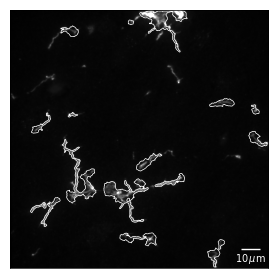

In [11]:
microglia_image_saver_3D(
    [filenames[1]], oligomer_data_HC, ski.filters.threshold_otsu, folder_to_save
)

In [12]:
def microglia_image_saver_generator(
    filename,
    oligomer_analysis,
    filter,
    protein_string="C1",
    cell_string="C0",
    lower_object_size=2000,
    lower_hole_size=100,
):
    if not os.path.isdir(folder_to_save):
        os.mkdir(folder_to_save)
    filename = str(filename)
    specific_image = oligomer_analysis.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    zi = int(np.unique(specific_image["zi"].to_numpy()))
    zf = int(np.unique(specific_image["zf"].to_numpy()))
    cell_filename = (
        overall_filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    )
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]
    mask = detect_large_features(
        raw_cell_image,
        filter,
        sigma1=2.0,
        sigma2=40.0,
        hole_threshold=100,
        cell_threshold=2000,
    )
    mask_toplot = np.sum(mask, axis=0).clip(0, 1)
    return mask_toplot, raw_cell_image

In [13]:
def microglia_image_saver_specificfile(
    mask_toplot,
    raw_cell_image,
    filename,
    oligomer_analysis,
    folder_to_save,
    xmin,
    xmax,
    ymin,
    ymax,
    protein_string="C1",
    cell_string="C0",
    lower_object_size=2000,
    lower_hole_size=100,
):
    if not os.path.isdir(folder_to_save):
        os.mkdir(folder_to_save)
    filename = str(filename)
    specific_image = oligomer_analysis.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    fig, axs = plotter.one_column_plot()
    savestring = (
        os.path.split(overall_filename)[-1].split(protein_string + ".tif")[0]
        + cell_string
        + "_examplemicroglia.svg"
    )
    axs[0] = plotter.image_plot(
        axs=axs[0],
        data=raw_cell_image.sum(axis=0)[xmin:xmax, ymin:ymax],
        plotmask=True,
        mask=mask_toplot[xmin:xmax, ymin:ymax],
        masklinewidth=0.5,
    )
    plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format="svg")
    plt.show(block=False)
    return

In [14]:
filename_HC_microglia = filenames[1]

In [15]:
mask_toplot, raw_cell_image = microglia_image_saver_generator(
    filename_HC_microglia, oligomer_data_HC, ski.filters.threshold_otsu
)

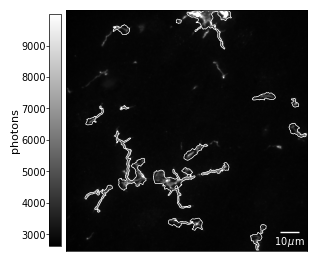

In [16]:
microglia_image_saver_specificfile(
    mask_toplot,
    raw_cell_image,
    filename_HC_microglia,
    oligomer_data_HC,
    folder_to_save,
    0,
    1200,
    0,
    1200,
)

In [17]:
def plot_microglia_with_oligomers(
    filename,
    oligomer_data,
    filter,
    folder_to_save,
    protein_string="C1",
    cell_string="C0",
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    labelval=None,
    alpha_threshold=0.0,
    show_oligomers=True,
    scalebarsize=10000,
    scalebarlabel="10 µm",
    lower_object_size=2000,
    lower_hole_size=100,
):
    """
    Plot microglia cell with optional oligomer overlay.

    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomer_data : polars.DataFrame
        DataFrame containing oligomer data with columns: image_filename, x, y, alpha, zi, zf
    filter : callable
        Threshold filter function (e.g., ski.filters.threshold_otsu)
    folder_to_save : str
        Directory to save output plots
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for plotting
    labelval : int, optional
        Specific label value to plot. If None, uses combined mask
    alpha_threshold : float
        Minimum alpha value for oligomer filtering (default 0.0)
    show_oligomers : bool
        Whether to overlay oligomer positions on the plot (default True)
    scalebarsize : int
        Size of scale bar in nm (default 10000)
    scalebarlabel : str
        Label for scale bar (default '10 µm')

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    oligomers_in_cell : polars.DataFrame or None
        Filtered oligomers inside the selected label
    """
    if not os.path.isdir(folder_to_save):
        os.mkdir(folder_to_save)

    filename = str(filename)
    specific_image = oligomer_data.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    zi = int(np.unique(specific_image["zi"].to_numpy()))
    zf = int(np.unique(specific_image["zf"].to_numpy()))

    # Load protein and cell images
    cell_filename = (
        overall_filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    )
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]
    raw_protein_image = IO.read_tiff_tophotons(overall_filename)[zi - 1 : zf - 1, :, :]

    # Create cell mask
    mask = detect_large_features(
        raw_cell_image,
        filter,
        sigma1=2.0,
        sigma2=40.0,
        hole_threshold=lower_hole_size,
        cell_threshold=lower_object_size,
    )

    # Label individual cells
    labeled_image = label(mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)

    # Create MIP for cell channel (what we'll plot as background)
    cell_MIP = np.max(raw_cell_image, axis=0)

    oligomers_in_cell = None
    fig, axs = plotter.one_column_plot()

    if labelval is not None:
        # Filter to specific label
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1
    else:
        # Use all cells
        mask_toplot_filtered = (mask_toplot > 0).astype(int)

    # Filter oligomers if data provided and show_oligomers is True
    if oligomer_data is not None and show_oligomers:
        # Get oligomers for this image
        oligomers = oligomer_data.filter(
            pl.col("image_filename").str.contains(filename, literal=True)
        )
        oligomers = oligomers.filter(pl.col("alpha") >= alpha_threshold)

        if len(oligomers) > 0:
            x = oligomers["x"].to_numpy()
            y = oligomers["y"].to_numpy()
            alpha = oligomers["alpha"].to_numpy()

            # Generate indices for mask and spots
            centroids = np.vstack([np.array(x, dtype=int), np.array(y, dtype=int)]).T
            mask_indices = A_F.generate_indices(
                np.array(mask_toplot_filtered, dtype=bool), (1200, 1200), is_mask=True
            )
            spot_indices = A_F.generate_indices(centroids, (1200, 1200))
            spot_indices = C_F._apply_blur(spot_indices, (1200, 1200), 1)

            # Test which oligomers are inside the cell
            in_cell = C_F.test_spot_spot_overlap(
                spot_indices, mask_indices, n_spot1=len(x), raw=True
            )

            # Filter oligomers
            oligomers_in_cell = oligomers.filter(pl.lit(in_cell))

            print(f"Found {len(oligomers_in_cell)} oligomers inside cell(s)")
            print(f"  Total oligomers in image: {len(oligomers)}")
            if len(oligomers) > 0:
                print(
                    f"  Percentage in cell: {100*len(oligomers_in_cell)/len(oligomers):.2f}%"
                )

            # Plot oligomers over CELL image (not protein image)
            x_in = oligomers_in_cell["x"].to_numpy()
            y_in = oligomers_in_cell["y"].to_numpy()
            alpha_in = oligomers_in_cell["alpha"].to_numpy()

            # Filter to plotting region
            plot_indices = (
                (x_in >= xmin) & (x_in < xmax) & (y_in >= ymin) & (y_in < ymax)
            )
            x_plot = x_in[plot_indices] - xmin
            y_plot = y_in[plot_indices] - ymin
            alpha_plot = alpha_in[plot_indices]

            axs[0] = plotter.image_scatter_plot(
                axs=axs[0],
                data=cell_MIP[xmin:xmax, ymin:ymax],
                xdata=x_plot,
                ydata=y_plot,
                facecolor="red",
                alpha_scatter=alpha_plot,
                s=10,
                lws=0,
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel=scalebarlabel,
            )
            axs[0].contour(
                mask_toplot_filtered[xmin:xmax, ymin:ymax],
                [0.5],
                lw=0.75,
                colors="white",
            )
        else:
            print(f"No oligomers found in image with alpha >= {alpha_threshold}")
            axs[0] = plotter.image_plot(
                axs=axs[0],
                data=cell_MIP[xmin:xmax, ymin:ymax],
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel=scalebarlabel,
            )
            axs[0].contour(
                mask_toplot_filtered[xmin:xmax, ymin:ymax],
                [0.5],
                lw=0.75,
                colors="white",
            )
    else:
        # No oligomer overlay - plot cell image only
        axs[0] = plotter.image_plot(
            axs=axs[0],
            data=cell_MIP[xmin:xmax, ymin:ymax],
            cbar="off",
            scalebarsize=scalebarsize,
            scalebarlabel=scalebarlabel,
        )
        axs[0].contour(
            mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white"
        )

    return fig, axs, oligomers_in_cell

In [18]:
def plot_labeled_cells(
    filename,
    oligomer_data,
    filter,
    protein_string="C1",
    cell_string="C0",
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    scalebarsize=10000,
    scalebarlabel="10 µm",
    lower_object_size=2000,
    lower_hole_size=100,
    show_labels=True,
    min_area=200,
):
    """
    Plot all labeled cells with unique colored boundaries.

    This is useful for identifying which cell label to use for detailed analysis.

    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomer_data : polars.DataFrame
        DataFrame containing oligomer data
    filter : callable
        Threshold filter function
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for plotting
    scalebarsize : int
        Size of scale bar in nm (default 10000)
    scalebarlabel : str
        Label for scale bar (default '10 µm')
    show_labels : bool
        Whether to show label numbers on cells (default True)
    min_area : int
        Minimum area in pixels to include a cell (default 200)

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    labeled_image : numpy array
        3D labeled image with cell labels
    """
    filename = str(filename)
    specific_image = oligomer_data.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    zi = int(np.unique(specific_image["zi"].to_numpy()))
    zf = int(np.unique(specific_image["zf"].to_numpy()))

    # Load cell image
    cell_filename = (
        overall_filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    )
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]

    # Create and label cell mask
    mask = detect_large_features(
        raw_cell_image,
        filter,
        sigma1=2.0,
        sigma2=40.0,
        hole_threshold=lower_hole_size,
        cell_threshold=lower_object_size,
    )
    labeled_image = label(mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)

    # Create MIP for cell channel
    cell_MIP = np.max(raw_cell_image, axis=0)

    # Create plot
    fig, axs = plotter.one_column_plot()
    axs[0] = plotter.image_plot(
        axs=axs[0],
        data=cell_MIP[xmin:xmax, ymin:ymax],
        cbar="off",
        masklinewidth=0.5,
        scalebarlabel=scalebarlabel,
        scalebarsize=scalebarsize,
    )

    # Get unique labels (excluding background 0)
    unique_labels = np.unique(mask_toplot)
    unique_labels = unique_labels[unique_labels > 0]

    # Filter labels by area using regionprops
    from skimage.measure import regionprops

    filtered_labels = []
    for label_val in unique_labels:
        # Create binary mask for this label
        single_cell_mask = (mask_toplot == label_val).astype(int)

        # Get region properties in the cropped view
        props = regionprops(single_cell_mask[xmin:xmax, ymin:ymax])

        if len(props) > 0:
            area = props[0].area
            if area >= min_area:
                filtered_labels.append(label_val)

    filtered_labels = np.array(filtered_labels)

    print(f"Found {len(unique_labels)} total cells")
    print(f"After area filter (>={min_area} pixels): {len(filtered_labels)} cells")
    print(f"Filtered cell labels: {filtered_labels}")

    # Generate unique colors for each cell
    import matplotlib.cm as cm

    colors = cm.get_cmap("hsv", len(filtered_labels) + 1)

    # Draw contours for each cell with unique colors
    for idx, label_val in enumerate(filtered_labels):
        # Create binary mask for this label
        single_cell_mask = (mask_toplot == label_val).astype(int)

        # Get unique color for this cell
        color = colors(idx / len(filtered_labels))

        # Draw contour with unique color
        axs[0].contour(
            single_cell_mask[xmin:xmax, ymin:ymax], [0.5], lw=1.5, colors=[color]
        )

        # Add label number at centroid if requested
        if show_labels:
            props = regionprops(single_cell_mask[xmin:xmax, ymin:ymax])
            if len(props) > 0:
                centroid = props[0].centroid
                axs[0].text(
                    centroid[1],
                    centroid[0],
                    str(label_val),
                    color=color,
                    fontsize=10,
                    weight="bold",
                    ha="center",
                    va="center",
                    bbox=dict(
                        boxstyle="circle,pad=0.3",
                        facecolor="black",
                        edgecolor=color,
                        linewidth=1.5,
                        alpha=0.8,
                    ),
                )

    return fig, axs, labeled_image

In [19]:
def get_cell_bounding_box(
    labeled_image, labelval, square_plot_border=10, make_square=True
):
    """
    Get bounding box coordinates for a specific cell label.

    Parameters:
    -----------
    labeled_image : numpy array
        3D labeled image with cell labels
    labelval : int
        Cell label number to get bounding box for
    square_plot_border : int
        Number of pixels to add as border around the cell (default 10)
    make_square : bool
        Whether to make the crop square (default True)

    Returns:
    --------
    xmin, xmax, ymin, ymax : int
        Bounding box coordinates for cropping
    """
    from skimage.measure import regionprops

    # Get 2D projection of labeled image
    mask_2d = np.max(labeled_image, axis=0)

    # Create binary mask for this specific label
    single_cell_mask = (mask_2d == labelval).astype(int)

    # Get region properties
    props = regionprops(single_cell_mask)

    if len(props) == 0:
        raise ValueError(f"Label {labelval} not found in image")

    # Get bounding box (minr, minc, maxr, maxc)
    bbox = props[0].bbox
    minr, minc, maxr, maxc = bbox

    # Add border
    minr = max(0, minr - square_plot_border)
    minc = max(0, minc - square_plot_border)
    maxr = min(mask_2d.shape[0], maxr + square_plot_border)
    maxc = min(mask_2d.shape[1], maxc + square_plot_border)

    if make_square:
        # Make it square by expanding the smaller dimension
        height = maxr - minr
        width = maxc - minc

        if height > width:
            # Expand width
            diff = height - width
            minc = max(0, minc - diff // 2)
            maxc = min(mask_2d.shape[1], maxc + (diff - diff // 2))
        elif width > height:
            # Expand height
            diff = width - height
            minr = max(0, minr - diff // 2)
            maxr = min(mask_2d.shape[0], maxr + (diff - diff // 2))

    print(f"Cell {labelval} bounding box: x=[{minr}, {maxr}], y=[{minc}, {maxc}]")
    print(f"  Size: {maxr-minr} x {maxc-minc} pixels")

    return minr, maxr, minc, maxc


def square_plot_cell(
    filename,
    oligomer_data,
    filter,
    labelval,
    protein_string="C1",
    cell_string="C0",
    square_plot_border=10,
    scalebarsize=5000,
    scalebarlabel="5 µm",
    lower_object_size=2000,
    lower_hole_size=100,
):
    """
    Automatically create a square plot around a specific cell using its bounding box.

    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomer_data : polars.DataFrame
        DataFrame containing oligomer data
    filter : callable
        Threshold filter function
    labelval : int
        Cell label number to plot
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    square_plot_border : int
        Number of pixels to add as border around the cell (default 10)
    scalebarsize : int
        Size of scale bar in nm (default 5000)
    scalebarlabel : str
        Label for scale bar (default '5 µm')

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    xmin, xmax, ymin, ymax : int
        Bounding box coordinates used for cropping
    """
    filename = str(filename)
    specific_image = oligomer_data.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    zi = int(np.unique(specific_image["zi"].to_numpy()))
    zf = int(np.unique(specific_image["zf"].to_numpy()))

    # Load cell image
    cell_filename = (
        overall_filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    )
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]

    # Create and label cell mask
    mask = detect_large_features(
        raw_cell_image,
        filter,
        sigma1=2.0,
        sigma2=40.0,
        hole_threshold=lower_hole_size,
        cell_threshold=lower_object_size,
    )
    labeled_image = label(mask, connectivity=3, return_num=False)

    # Get bounding box for this cell
    xmin, xmax, ymin, ymax = get_cell_bounding_box(
        labeled_image, labelval, square_plot_border=square_plot_border, make_square=True
    )

    # Get 2D mask and cell MIP
    mask_toplot = np.max(labeled_image, axis=0)
    cell_MIP = np.max(raw_cell_image, axis=0)

    # Filter to specific label
    mask_toplot_filtered = mask_toplot.copy()
    mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
    mask_toplot_filtered[mask_toplot_filtered == labelval] = 1

    # Create plot
    fig, axs = plotter.one_column_plot()
    axs[0] = plotter.image_plot(
        axs=axs[0],
        data=cell_MIP[xmin:xmax, ymin:ymax],
        cbar="off",
        masklinewidth=0.5,
        scalebarlabel=scalebarlabel,
        scalebarsize=scalebarsize,
    )

    # Add mask contour
    axs[0].contour(
        mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white"
    )

    return fig, axs, xmin, xmax, ymin, ymax

Found 20 total cells
After area filter (>=200 pixels): 20 cells
Filtered cell labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


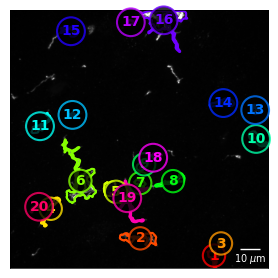

In [20]:
# Example: Plot all labeled cells with unique colored boundaries
# Cells are filtered by area (min_area=200 pixels by default)
fig, axs, labeled_image = plot_labeled_cells(
    filename_HC_microglia,
    oligomer_data_HC,
    ski.filters.threshold_otsu,
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
    show_labels=True,
    min_area=200,  # Only show cells with area >= 200 pixels
)

savestring = (
    os.path.split(filename_HC_microglia)[-1].split("_C1.tif")[0] + "_labeled_cells.svg"
)
plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format="svg")
plt.show(block=False)

Cell 19 bounding box: x=[203, 417], y=[449, 663]
  Size: 214 x 214 pixels


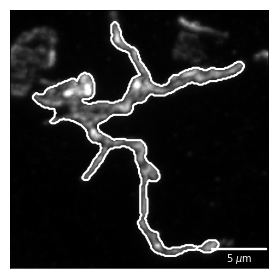


Use these coordinates for oligomer overlay:
xmin=203, xmax=417, ymin=449, ymax=663


In [21]:
# Example: Automatically create a square plot around a specific cell
# First, look at the labeled cells plot above to choose which cell you want (e.g., cell label 1)
cell_to_plot = 19  # Change this to the label number you want

fig, axs, xmin, xmax, ymin, ymax = square_plot_cell(
    filename_HC_microglia,
    oligomer_data_HC,
    ski.filters.threshold_otsu,
    labelval=cell_to_plot,
    square_plot_border=10,  # Add 10 pixels border around the cell
    scalebarsize=5000,
    scalebarlabel=r"5 $\mu$m",
)

savestring = (
    os.path.split(filename_HC_microglia)[-1].split("_C1.tif")[0]
    + f"_cell{cell_to_plot}_square.svg"
)
# plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format='svg')
plt.show(block=False)

print(f"\nUse these coordinates for oligomer overlay:")
print(f"xmin={xmin}, xmax={xmax}, ymin={ymin}, ymax={ymax}")

Found 138 oligomers inside cell(s)
  Total oligomers in image: 18795
  Percentage in cell: 0.73%


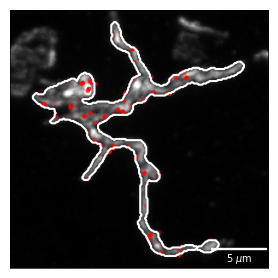


Found 138 oligomers in cell 19


In [22]:
# Example: Now use those coordinates to plot the same cell with oligomers overlaid
fig, axs, oligomers_in_cell = plot_microglia_with_oligomers(
    filename_HC_microglia,
    oligomer_data_HC,
    ski.filters.threshold_otsu,
    folder_to_save,
    xmin=xmin,
    xmax=xmax,
    ymin=ymin,
    ymax=ymax,  # Use coordinates from square_plot_cell
    labelval=cell_to_plot,  # Same cell
    alpha_threshold=0.0,
    show_oligomers=True,
    scalebarsize=5000,
    scalebarlabel=r"5 $\mu$m",
)

savestring = (
    os.path.split(filename_HC_microglia)[-1].split("_C1.tif")[0]
    + f"_cell{cell_to_plot}_with_oligomers.svg"
)
plt.savefig(os.path.join(folder_to_save, savestring), dpi=600, format="svg")
plt.show(block=False)

if oligomers_in_cell is not None:
    print(f"\nFound {len(oligomers_in_cell)} oligomers in cell {cell_to_plot}")

In [26]:
def plot_individual_oligomers(
    filename,
    oligomers_in_cell,
    protein_string="C1",
    cell_string="C0",
    box_size=20,
    max_oligomers=None,
    scalebarsize=300,
    scalebarlabel="300 nm",
    sort_by_intensity=True,
    raw_protein_image=None,
):
    """
    Plot individual oligomers in a multi-panel grid.

    For each oligomer, finds the brightest pixel in a local region and
    centers the plot on that pixel.

    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomers_in_cell : polars.DataFrame
        DataFrame with oligomers (must have x, y, z, alpha, sum_intensity_in_photons columns)
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    box_size : int
        Size of the box around each oligomer in pixels (default 20)
    max_oligomers : int, optional
        Maximum number of oligomers to plot. If None, plots all
    scalebarsize : int
        Size of scale bar in nm (default 300)
    scalebarlabel : str
        Label for scale bar (default '300 nm')
    sort_by_intensity : bool
        Whether to sort oligomers by intensity (brightest first, default True)
    raw_protein_image : numpy array, optional
        Pre-loaded protein image stack. If None, will load from filename.
        For multiple calls with same image, pre-load and pass to avoid reloading.

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    oligomer_coords : list of tuples
        List of (x_center, y_center, z_plane) for each plotted oligomer
    """
    if oligomers_in_cell is None or len(oligomers_in_cell) == 0:
        print("No oligomers to plot!")
        return None, None, None

    # Get zi and zf to only load relevant z-planes (much faster!)
    zi = int(oligomers_in_cell["zi"][0])
    zf = int(oligomers_in_cell["zf"][0])

    # Load only the relevant z-planes from protein image if not provided
    if raw_protein_image is None:
        raw_protein_image = IO.read_tiff_tophotons(filename)[zi - 1 : zf, :, :]
        print(f"Loaded z-planes {zi} to {zf} (shape: {raw_protein_image.shape})")
    else:
        print(f"Using pre-loaded image (shape: {raw_protein_image.shape})")

    # Sort by intensity if requested
    if sort_by_intensity:
        oligomers_to_plot = oligomers_in_cell.sort(
            "sum_intensity_in_photons", descending=True
        )
    else:
        oligomers_to_plot = oligomers_in_cell

    # Limit number of oligomers if specified
    if max_oligomers is not None:
        oligomers_to_plot = oligomers_to_plot.head(max_oligomers)

    n_oligomers = len(oligomers_to_plot)
    print(f"Plotting {n_oligomers} oligomers")

    # Calculate grid dimensions (roughly square)
    n_cols = int(np.ceil(np.sqrt(n_oligomers)))
    n_rows = int(np.ceil(n_oligomers / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3, 6))
    if n_oligomers == 1:
        axs = np.array([axs])
    axs = axs.flatten()

    oligomer_coords = []

    for idx in range(n_oligomers):
        oligomer = oligomers_to_plot[idx]

        # Get initial coordinates from database
        x_init = int(oligomer["x"][0])
        y_init = int(oligomer["y"][0])
        z_db = int(oligomer["z"][0])  # Database z-coordinate (1-indexed)

        # Convert to 0-indexed and make relative to zi
        z_plane = z_db - zi  # Now it's relative to our loaded subset

        # Get a search region around the initial coordinate
        search_size = box_size
        x_min_search = max(0, x_init - search_size)
        x_max_search = min(raw_protein_image.shape[1], x_init + search_size)
        y_min_search = max(0, y_init - search_size)
        y_max_search = min(raw_protein_image.shape[2], y_init + search_size)

        # Extract search region from the z-plane
        search_region = raw_protein_image[
            z_plane, x_min_search:x_max_search, y_min_search:y_max_search
        ]

        # Find brightest pixel (centroid) in search region
        if search_region.size > 0:
            max_idx = np.unravel_index(np.argmax(search_region), search_region.shape)
            x_center = x_min_search + max_idx[0]
            y_center = y_min_search + max_idx[1]
        else:
            # Fallback to initial coordinates if search region is invalid
            x_center = x_init
            y_center = y_init

        oligomer_coords.append(
            (x_center, y_center, z_db)
        )  # Store original z for reference

        # Extract box around the centered brightest pixel
        half_box = box_size // 2
        x_min = max(0, x_center - half_box)
        x_max = min(raw_protein_image.shape[1], x_center + half_box)
        y_min = max(0, y_center - half_box)
        y_max = min(raw_protein_image.shape[2], y_center + half_box)

        # Get the image patch
        oligomer_patch = raw_protein_image[z_plane, x_min:x_max, y_min:y_max]

        # Plot - show scale bar on first panel only
        if idx == 0:
            # Show scale bar with label on first panel
            axs[idx] = plotter.image_plot(
                axs=axs[idx],
                data=oligomer_patch,
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel=scalebarlabel,
            )
        else:
            # Show scale bar without label on other panels
            axs[idx] = plotter.image_plot(
                axs=axs[idx],
                data=oligomer_patch,
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel="",
            )

        # Add title with oligomer number and intensity
        intensity = oligomer["sum_intensity_in_photons"][0]
        alpha = oligomer["alpha"][0]
        axs[idx].set_title(
            f"#{idx+1}\nI={intensity:.0f}, α={alpha:.2f}", fontsize=6, pad=2
        )

    # Hide unused subplots
    for idx in range(n_oligomers, len(axs)):
        axs[idx].axis("off")

    plt.tight_layout()

    print(f"Created {n_rows}x{n_cols} grid showing {n_oligomers} oligomers")

    return fig, axs, oligomer_coords

Pre-loaded protein image: z-planes 1 to 25, shape (25, 1200, 1200)
Using pre-loaded image (shape: (25, 1200, 1200))
Plotting 4 oligomers
Created 2x2 grid showing 4 oligomers


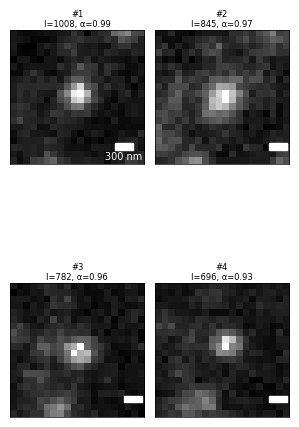


Re-centered oligomer coordinates (x, y, z):
  Oligomer 1: (230, 565, 25)
  Oligomer 2: (230, 565, 24)
  Oligomer 3: (339, 477, 16)
  Oligomer 4: (338, 477, 17)


In [27]:
# Pre-load the protein image once (only loads relevant z-planes)
zi = int(oligomers_in_cell["zi"][0])
zf = int(oligomers_in_cell["zf"][0])
raw_protein_image = IO.read_tiff_tophotons(filename_HC_microglia)[zi - 1 : zf, :, :]
print(
    f"Pre-loaded protein image: z-planes {zi} to {zf}, shape {raw_protein_image.shape}"
)

# Example: Plot individual oligomers found in the cell
# Now uses the pre-loaded image - much faster for repeated calls!
fig_oligomers, axs_oligomers, oligomer_coords = plot_individual_oligomers(
    filename_HC_microglia,
    oligomers_in_cell,
    box_size=20,  # 20x20 pixel boxes around each oligomer
    max_oligomers=4,  # Show top 9 brightest oligomers (or None for all)
    scalebarsize=300,
    scalebarlabel="300 nm",
    sort_by_intensity=True,  # Sort by brightness (brightest first)
    raw_protein_image=raw_protein_image,  # Pass pre-loaded image
)

if fig_oligomers is not None:
    savestring = (
        os.path.split(filename_HC_microglia)[-1].split("_C1.tif")[0]
        + f"_cell{cell_to_plot}_oligomer_grid.svg"
    )
    plt.savefig(
        os.path.join(folder_to_save, savestring),
        dpi=600,
        format="svg",
        bbox_inches="tight",
    )
    plt.show(block=False)

    # Print the re-centered coordinates
    print("\nRe-centered oligomer coordinates (x, y, z):")
    for i, (x, y, z) in enumerate(oligomer_coords):
        print(f"  Oligomer {i+1}: ({x}, {y}, {z})")

In [29]:
def plot_oligomer_context_panel(
    filename,
    oligomer_data,
    filter,
    oligomer_xmins,
    oligomer_xmaxs,
    oligomer_ymins,
    oligomer_ymaxs,
    protein_string="C1",
    cell_string="C0",
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    labelval=None,
    scalebarsize=10000,
    scalebarlabel="10 µm",
    label_boxes=True,
    lower_object_size=2000,
    lower_hole_size=100,
):
    """
    Create a context panel showing where oligomer visualization regions are located.

    Shows the cell with white boxes overlaid to indicate zoomed-in oligomer regions.

    Parameters:
    -----------
    filename : str
        Path to the image file
    oligomer_data : polars.DataFrame
        DataFrame containing oligomer data
    filter : callable
        Threshold filter function
    oligomer_xmins, oligomer_xmaxs, oligomer_ymins, oligomer_ymaxs : array-like
        Arrays of coordinates defining the zoomed oligomer regions
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for the cell view
    labelval : int, optional
        Specific cell label to highlight
    scalebarsize : int
        Size of scale bar in nm (default 10000)
    scalebarlabel : str
        Label for scale bar (default '10 µm')
    label_boxes : bool
        Whether to add numerical labels to each box (default True)

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    """
    filename = str(filename)
    specific_image = oligomer_data.filter(
        pl.col("image_filename").str.contains(filename, literal=True)
    )
    overall_filename = str(np.unique(specific_image["image_filename"].to_numpy())[0])
    zi = int(np.unique(specific_image["zi"].to_numpy()))
    zf = int(np.unique(specific_image["zf"].to_numpy()))

    # Load cell and protein images
    cell_filename = (
        overall_filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    )
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]
    raw_protein_image = IO.read_tiff_tophotons(overall_filename)[zi - 1 : zf - 1, :, :]

    # Create and label cell mask
    mask = detect_large_features(
        raw_cell_image,
        filter,
        sigma1=2.0,
        sigma2=40.0,
        hole_threshold=lower_hole_size,
        cell_threshold=lower_object_size,
    )
    labeled_image = label(mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)

    # Create MIP for cell channel (background image)
    cell_MIP = np.max(raw_cell_image, axis=0)

    # Filter to specific label if provided
    if labelval is not None:
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1
    else:
        mask_toplot_filtered = (mask_toplot > 0).astype(int)

    # Create plot with cell image as background
    fig, axs = plotter.one_column_plot()
    axs[0] = plotter.image_plot(
        axs=axs[0],
        data=cell_MIP[xmin:xmax, ymin:ymax],
        cbar="off",
        masklinewidth=0.5,
        scalebarlabel=scalebarlabel,
        scalebarsize=scalebarsize,
    )

    # Add mask contour
    axs[0].contour(
        mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white"
    )

    # Draw white boxes showing oligomer regions
    from matplotlib.patches import Rectangle

    for i in np.arange(len(oligomer_xmins)):
        olig_xmin = oligomer_xmins[i]
        olig_xmax = oligomer_xmaxs[i]
        olig_ymin = oligomer_ymins[i]
        olig_ymax = oligomer_ymaxs[i]

        # Convert to coordinates relative to the cropped view
        rect = Rectangle(
            (olig_ymin - ymin, olig_xmin - xmin),
            olig_ymax - olig_ymin,
            olig_xmax - olig_xmin,
            linewidth=2,
            edgecolor="white",
            facecolor="none",
            linestyle="--",
        )
        axs[0].add_patch(rect)

        # Add numerical labels to boxes
        if label_boxes:
            axs[0].text(
                olig_ymin - ymin + 3,
                olig_xmin - xmin + 3,
                str(i + 1),
                color="white",
                fontsize=10,
                weight="bold",
                verticalalignment="top",
                horizontalalignment="left",
                bbox=dict(
                    boxstyle="square,pad=0.3",
                    facecolor="black",
                    edgecolor="white",
                    linewidth=1,
                    alpha=0.7,
                ),
            )

    return fig, axs

In [28]:
# Optional: Show where these oligomers are located on the cell
# This creates a context panel with boxes showing the location of each plotted oligomer

if oligomer_coords is not None and len(oligomer_coords) > 0:
    # Extract coordinates from oligomer_coords list
    oligomer_xs = np.array([coord[0] for coord in oligomer_coords])
    oligomer_ys = np.array([coord[1] for coord in oligomer_coords])

    # Create boxes around each oligomer (20x20 boxes)
    half_box = 10
    oligomer_xmins = oligomer_xs - half_box
    oligomer_xmaxs = oligomer_xs + half_box
    oligomer_ymins = oligomer_ys - half_box
    oligomer_ymaxs = oligomer_ys + half_box

    # Plot context showing where all oligomers are
    fig_context, axs_context = plot_oligomer_context_panel(
        filename_HC_microglia,
        oligomer_data_HC,
        ski.filters.threshold_otsu,
        oligomer_xmins=oligomer_xmins,
        oligomer_xmaxs=oligomer_xmaxs,
        oligomer_ymins=oligomer_ymins,
        oligomer_ymaxs=oligomer_ymaxs,
        xmin=xmin,
        xmax=xmax,  # Use same crop as cell plot
        ymin=ymin,
        ymax=ymax,
        labelval=cell_to_plot,
        scalebarsize=5000,
        scalebarlabel=r"5 $\mu$m",
        label_boxes=True,  # Number each box 1, 2, 3, etc.
    )

    savestring = (
        os.path.split(filename_HC_microglia)[-1].split("_C1.tif")[0]
        + f"_cell{cell_to_plot}_oligomer_context.svg"
    )
    plt.savefig(
        os.path.join(folder_to_save, savestring),
        dpi=600,
        format="svg",
        bbox_inches="tight",
    )
    plt.show(block=False)

NameError: name 'plot_oligomer_context_panel' is not defined